In [46]:
import copy
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

In [16]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "cifar10_baseline.pt"
)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)

Project root: /Users/cedric/Repos/vit-reimplementation
Data root: /Users/cedric/Repos/vit-reimplementation/data


In [17]:
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size: tuple[int, int],
        patch_size: tuple[int, int],
        channels: int,
        dim: int,
    ) -> None:
        super().__init__()

        if len(image_size) != 2:
            raise ValueError(
                f"Expected 2 dimension image_size but got {len(image_size)}"
            )
        if len(patch_size) != 2:
            raise ValueError(
                f"Expected 2 dimension patch_size but got {len(patch_size)}"
            )
        if not all(x > 0 for x in image_size):
            raise ValueError(
                f"Expected image_size with positive dimensions but got {image_size}"
            )
        if not all(x > 0 for x in patch_size):
            raise ValueError(
                f"Expected patch_size positive dimensions but got {patch_size}"
            )
        if ((image_size[0] % patch_size[0]) != 0) or ((image_size[1] % patch_size[1]) != 0):
            raise ValueError(
                f"Expected image_size divisible by patch_size but got image_size {image_size} and patch_size {patch_size}"
            )
        if not channels > 0:
            raise ValueError(
                f"Expected positive number of channels but got {channels}"
            )
        if not dim > 0:
            raise ValueError(
                f"Expected positive number of dims but got {dim}"
            )

        self.channels = channels
        self.dim = dim
        self.image_height = image_size[0]
        self.image_width = image_size[1]
        self.patch_height = patch_size[0]
        self.patch_width = patch_size[1]
        self.num_patches_h = self.image_height // self.patch_height
        self.num_patches_w = self.image_width // self.patch_width
        self.num_patches = self.num_patches_h * self.num_patches_w
        self.patch_dim = self.patch_height * self.patch_width * channels

        self.project = nn.Linear(
            in_features = self.patch_dim,
            out_features = dim
        )
        
    def forward(
        self,
        images: torch.Tensor,
    ) -> torch.Tensor:
        patches = self.patchify(images)
        embeddings = self.project(patches)
        
        return embeddings

    def patchify(
        self,
        images: torch.Tensor
    ) -> torch.Tensor:
        if images.ndim != 4:
            raise ValueError(
                f"Expected 4 dimension images, but got {images.ndim} dimensions"
            )
        if images.shape[1] != self.channels:
            raise ValueError(
                f"Expected {self.channels} channels but got {images.shape[1]} channels"
            )
        if images.shape[2] != self.image_height:
            raise ValueError(
                f"Expected height {self.image_height} but got {images.shape[2]}"
            )
        if images.shape[3] != self.image_width:
            raise ValueError(
                f"Expected width {self.image_width} but got {images.shape[3]}"
            )

        batch_size = images.shape[0]
            
        images = images.reshape(batch_size, self.channels, self.num_patches_h, self.patch_height, self.num_patches_w, self.patch_width,)
        images = images.permute(0, 2, 4, 3, 5, 1)
        images = images.reshape(batch_size, self.num_patches, self.patch_dim)
        
        return images     

In [18]:
embed = PatchEmbedding(
    [4, 4],
    [2, 2],
    1,
    2
)

sample = torch.tensor(
    [
        [
            [
                [0.0, 1.0, 2.0, 3.0],
                [4.0, 5.0, 6.0, 7.0],
                [8.0, 9.0, 10.0, 11.0],
                [12.0, 13.0, 14.0, 15.0]
            ]
        ]
    ]
)

sample.shape, sample

(torch.Size([1, 1, 4, 4]),
 tensor([[[[ 0.,  1.,  2.,  3.],
           [ 4.,  5.,  6.,  7.],
           [ 8.,  9., 10., 11.],
           [12., 13., 14., 15.]]]]))

In [19]:
sample_emb = embed(sample)
sample_emb.shape, sample_emb

(torch.Size([1, 4, 2]),
 tensor([[[ 0.6370,  1.6039],
          [ 0.4701,  3.5476],
          [-0.0307,  9.3786],
          [-0.1976, 11.3222]]], grad_fn=<ViewBackward0>))

In [20]:
sample_patchify = embed.patchify(sample)
sample_patchify.shape, sample_patchify

(torch.Size([1, 4, 4]),
 tensor([[[ 0.,  1.,  4.,  5.],
          [ 2.,  3.,  6.,  7.],
          [ 8.,  9., 12., 13.],
          [10., 11., 14., 15.]]]))

In [21]:
class FeedForward(nn.Module):
    def __init__(
        self,
        dim,
        hidden_dim
    ) -> None:
        super().__init__()

        self.dim = dim

        self.linear_layer_1 = nn.Linear(
            dim,
            hidden_dim
        )

        self.gelu_layer = nn.GELU()

        self.linear_layer_2 = nn.Linear(
            hidden_dim,
            dim
        )
        
    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        if x.shape[-1] != self.dim:
            raise ValueError(
                f"Expected final dimension {self.dim} but got {x.shape[-1]}"
            )
            
        x_l1 = self.linear_layer_1(x)
        x_gelu = self.gelu_layer(x_l1)
        out = self.linear_layer_2(x_gelu)

        return out     

In [22]:
class Attention(nn.Module):
    def __init__(
        self,
    ) -> None:
        super().__init__()

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        tensors = [query, key, value]

        for tensor in tensors:
            if tensor.ndim!= 4:
                raise ValueError(
                    f"Expected tensor rank 4, but got {tensor.ndim}"
                )
        if not (query.shape[:2] == key.shape[:2] == value.shape[:2]):
            raise ValueError(
                "Expected query, key, and value to have matching batch size "
                f"and heads, but got query: {query.shape}, key: {key.shape}, "
                f"value: {value.shape}"
            )
        if query.shape[-1] != key.shape[-1]:
            raise ValueError(
                "Expected query and key to have matching head dimensions, "
                f"but got query head dimensions: {query.shape[-1]}, "
                f"key head dimensions: {key.shape[-1]}"
            )
        if key.shape[2] != value.shape[2]:
            raise ValueError(
                "Expected key and value to have matching sequence lengths, "
                f"but got key sequence length: {key.shape[2]}, "
                f"value sequence length: {value.shape[2]}"
            )

        head_dim = query.shape[-1]

        scores = (
            query @ key.transpose(-2, -1)
        ) / (head_dim ** 0.5)

        weights = F.softmax(scores, dim=-1)
        output = weights @ value

        return output, weights

class MultiheadAttention(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
    ) -> None:
        super().__init__()

        if not d_model > 0:
            raise ValueError(
                f"Expected positive d_model but got {d_model}"
            )
        if not num_heads > 0:
            raise ValueError(
                f"Expected positive num_heads but got {num_heads}"
            )
        if not ((d_model % num_heads) == 0):
            raise ValueError(
                f"Expected num_heads to divide d_model but got d_model {d_model}, and num_heads {num_heads}"
            )

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.project_query = nn.Linear(
            in_features=d_model,
            out_features=d_model,
            bias=False,
        )
        self.project_key = nn.Linear(
            in_features=d_model,
            out_features=d_model,
            bias=False,
        )
        self.project_value = nn.Linear(
            in_features=d_model,
            out_features=d_model,
            bias=False,
        )
        self.project_output = nn.Linear(
            in_features=d_model,
            out_features=d_model,
            bias=False,
        )

        self.attention = Attention()

    def split_heads(
        self,
        tensor: torch.Tensor
    ) -> torch.Tensor:

        if tensor.ndim != 3:
            raise ValueError(
                f"Expected rank-3 tensor, but got {tensor.ndim}"
            )
        if tensor.shape[-1] != self.d_model:
            raise ValueError(
                f"Expected final dimension {self.d_model}, but got {tensor.shape[-1]}"
            )
        
        batch_size, sequence_length, _ = tensor.shape
        
        out = tensor.reshape(batch_size, sequence_length, self.num_heads, self.d_head)

        return out.transpose(1, 2)

    def combine_heads(
        self,
        tensor: torch.Tensor
    ) -> torch.Tensor:

        if tensor.ndim != 4:
            raise ValueError(
                f"Expected rank-4 tensor, but got {tensor.ndim}"
            )
        if tensor.shape[1] != self.num_heads:
            raise ValueError(
                f"Expected num_heads {self.num_heads}, but got {tensor.shape[1]}"
            )
        if tensor.shape[-1] != self.d_head:
            raise ValueError(
                f"Expected head dimensions {self.d_head}, but got {tensor.shape[-1]}"
            )
            
        tensor = tensor.transpose(1, 2)

        batch_size, sequence_length, _, _ = tensor.shape

        out = tensor.reshape(batch_size, sequence_length, -1)

        return out

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        query, key, value = self.project_query(query), self.project_key(key), self.project_value(value)
        query, key, value = self.split_heads(query), self.split_heads(key), self.split_heads(value)

        output, weights = self.attention(
            query=query,
            key=key,
            value=value
        )

        output = self.combine_heads(output)
        output = self.project_output(output)

        return output, weights

In [23]:
class EncoderLayer(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        hidden_dim: int,
    ) -> None:
        super().__init__()

        self.layernorm1 = nn.LayerNorm(d_model)
        self.attention = MultiheadAttention(d_model, num_heads)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, hidden_dim)

    def forward(
        self,
        x: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        # Self Attention
        x_n = self.layernorm1(x)
        x_p, weights = self.attention(
            query=x_n,
            key=x_n,
            value=x_n)
        x = x + x_p

        # Feed Forward
        x_n2 = self.layernorm2(x)
        x_p2 = self.ffn(x_n2)
        output = x + x_p2

        return output, weights

In [24]:
class Transformer(nn.Module):
    def __init__(
        self,
        num_layers: int,
        d_model: int,
        num_heads: int,
        hidden_dim: int,
    ) -> None:
        super().__init__()
        
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(EncoderLayer(d_model, num_heads, hidden_dim,))

    def forward(
        self,
        x: torch.Tensor,
    ) -> tuple[torch.Tensor, list[torch.Tensor]]:

        all_weights = []

        output = x
        
        for layer in self.layers:
            output, weights = layer(output)
            all_weights.append(weights)

        return output, all_weights

In [25]:
class ViT(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        channels,
        dim,
        num_layers,
        num_heads,
        hidden_dim,
        num_classes,
    ) -> None:
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size,
            patch_size,
            channels,
            dim
        )
        
        self.num_patches = self.patch_embedding.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))

        self.pos_embedding = nn.Embedding(
            self.num_patches + 1,
            dim,
        )

        self.transformer = Transformer(
            num_layers=num_layers,
            d_model=dim,
            num_heads=num_heads,
            hidden_dim=hidden_dim,
        )

        self.project_classes = nn.Linear(
            in_features=dim,
            out_features=num_classes,
        )

        self.layernorm_final = nn.LayerNorm(dim)

    def forward(
        self,
        images: torch.Tensor
    ) -> tuple[torch.Tensor, list[torch.Tensor]]:

        x_emb = self.patch_embedding(images)
        
        batch_size = images.shape[0]
    
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        x_concat = torch.cat([cls_tokens, x_emb], dim=1)

        positions = torch.arange(start=0, end=self.num_patches + 1, device=x_emb.device).unsqueeze(0)

        x = x_concat + self.pos_embedding(positions)

        x_final, all_weights = self.transformer(x)

        x_final_norm = self.layernorm_final(x_final)

        logits = self.project_classes(x_final_norm[:, 0, :]) # Grabs the CLS token

        return logits, all_weights

In [26]:
def test_vit_forward_and_backward_contract() -> None:
    torch.manual_seed(0)

    batch_size = 2
    image_size = (32, 32)
    patch_size = (4, 4)
    channels = 3
    dim = 96
    num_layers = 3
    num_heads = 4
    hidden_dim = 384
    num_classes = 10

    num_patches = (
        (image_size[0] // patch_size[0])
        * (image_size[1] // patch_size[1])
    )
    sequence_length = num_patches + 1  # patches + CLS token

    model = ViT(
        image_size=image_size,
        patch_size=patch_size,
        channels=channels,
        dim=dim,
        num_layers=num_layers,
        num_heads=num_heads,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
    )

    images = torch.randn(
        batch_size,
        channels,
        image_size[0],
        image_size[1],
    )

    logits, all_weights = model(images)

    # One set of class logits per image.
    assert logits.shape == (batch_size, num_classes)
    assert logits.is_floating_point()
    assert torch.isfinite(logits).all()

    # One attention-weight tensor per encoder layer.
    assert len(all_weights) == num_layers

    for weights in all_weights:
        assert weights.shape == (
            batch_size,
            num_heads,
            sequence_length,
            sequence_length,
        )

        # Each query distributes a total weight of 1 over all keys.
        expected_sums = torch.ones(
            batch_size,
            num_heads,
            sequence_length,
            device=weights.device,
        )

        assert torch.allclose(
            weights.sum(dim=-1),
            expected_sums,
            atol=1e-6,
        )

        assert torch.isfinite(weights).all()

    # Verify that the output can train with classification loss.
    labels = torch.randint(
        low=0,
        high=num_classes,
        size=(batch_size,),
    )

    loss = F.cross_entropy(logits, labels)

    assert loss.ndim == 0
    assert torch.isfinite(loss)

    loss.backward()

    # Check that gradients reach the beginning and end of the model.
    important_parameters = {
        "patch projection": model.patch_embedding.project.weight,
        "CLS token": model.cls_token,
        "query projection": (
            model.transformer.layers[0]
            .attention.project_query.weight
        ),
        "classification head": model.project_classes.weight,
    }

    for name, parameter in important_parameters.items():
        assert parameter.grad is not None, (
            f"No gradient reached {name}"
        )
        assert torch.isfinite(parameter.grad).all(), (
            f"Non-finite gradient found in {name}"
        )

In [27]:
test_vit_forward_and_backward_contract()
print("ViT test passed")

ViT test passed


In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform,
)

In [30]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Class:", train_dataset.classes[label])

Image shape: torch.Size([3, 32, 32])
Image dtype: torch.float32
Label: 6
Class: frog


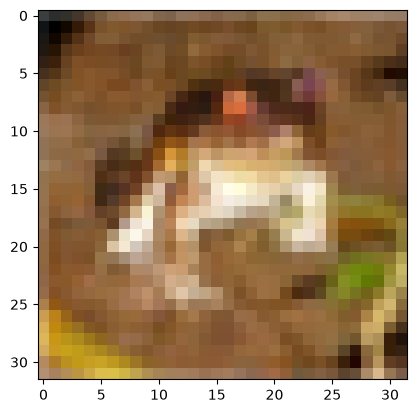

In [31]:
np_img = image.numpy()
plt_img = np.transpose(np_img, (1, 2, 0))

plt.imshow(plt_img)

In [32]:
torch.manual_seed(0)

subset_size = 64

indices = torch.randperm(
    len(train_dataset),
    generator=torch.Generator().manual_seed(0),
)[:subset_size]

tiny_dataset = Subset(
    train_dataset,
    indices.tolist(),
)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

In [33]:
images, labels = next(iter(tiny_loader))

print(images.shape)
print(labels.shape)
print(labels.dtype)

torch.Size([16, 3, 32, 32])
torch.Size([16])
torch.int64


In [34]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)

Using: mps


In [35]:
torch.manual_seed(0)

model = ViT(
    image_size=(32, 32),
    patch_size=(4, 4),
    channels=3,
    dim=96,
    num_layers=3,
    num_heads=4,
    hidden_dim=384,
    num_classes=10,
).to(device)

In [36]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> tuple[float, float]:
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(images)

        loss = F.cross_entropy(
            logits,
            labels,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        predictions = logits.argmax(dim=-1)

        batch_size = labels.shape[0]

        total_loss += loss.item() * batch_size
        total_correct += (
            predictions == labels
        ).sum().item()
        total_examples += batch_size

        running_loss = total_loss / total_examples
        running_accuracy = total_correct / total_examples

    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples

    return average_loss, accuracy

In [37]:
history = {
    "loss": [],
    "accuracy": [],
}

num_epochs = 100

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01,
)

for epoch in range(num_epochs):
    loss, accuracy = train_one_epoch(
        model=model,
        loader=tiny_loader,
        optimizer=optimizer,
        device=device,
    )

    history["loss"].append(loss)
    history["accuracy"].append(accuracy)

    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
        or accuracy >= 0.99
    ):
        print(
            f"Epoch {epoch + 1:3d} | "
            f"loss={loss:.4f} | "
            f"accuracy={accuracy:.2%}"
        )

    if accuracy >= 0.99:
        print("Tiny dataset memorized")
        break

Epoch   1 | loss=2.5137 | accuracy=10.94%
Epoch   5 | loss=2.3193 | accuracy=12.50%
Epoch  10 | loss=2.2643 | accuracy=14.06%
Epoch  15 | loss=2.2425 | accuracy=15.62%
Epoch  20 | loss=2.2208 | accuracy=9.38%
Epoch  25 | loss=2.1924 | accuracy=17.19%
Epoch  30 | loss=2.0617 | accuracy=25.00%
Epoch  35 | loss=1.9034 | accuracy=29.69%
Epoch  40 | loss=1.5902 | accuracy=48.44%
Epoch  45 | loss=1.3492 | accuracy=57.81%
Epoch  50 | loss=1.1552 | accuracy=56.25%
Epoch  55 | loss=0.9279 | accuracy=79.69%
Epoch  60 | loss=0.5949 | accuracy=87.50%
Epoch  65 | loss=0.3696 | accuracy=96.88%
Epoch  70 | loss=0.2126 | accuracy=98.44%
Epoch  73 | loss=0.1726 | accuracy=100.00%
Tiny dataset memorized


In [38]:
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    epoch=epoch,
    num_epochs=num_epochs,
) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)

            loss = F.cross_entropy(
                logits,
                labels
            )

            batch_size = labels.shape[0]

            total_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=-1)

            total_correct += (
                predictions == labels
            ).sum().item()
            total_examples += batch_size

        average_loss = total_loss / total_examples
        accuracy = total_correct / total_examples

    return average_loss, accuracy

In [40]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform,
)

full_val_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=eval_transform,
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=eval_transform,
)

In [41]:
num_examples = len(full_train_dataset)

num_val = 5_000
num_train = num_examples - num_val

generator = torch.Generator().manual_seed(0)

shuffled_indices = torch.randperm(
    num_examples,
    generator=generator,
)

train_indices = shuffled_indices[:num_train]
val_indices = shuffled_indices[num_train:]

train_dataset = Subset(
    full_train_dataset,
    train_indices.tolist(),
)

validation_dataset = Subset(
    full_val_dataset,
    val_indices.tolist(),
)

In [42]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(validation_dataset))
print("Test examples:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train examples: 45000
Validation examples: 5000
Test examples: 10000
Train batches: 352
Validation batches: 20
Test batches: 40


In [48]:
model = ViT(
    image_size=(32, 32),
    patch_size=(4, 4),
    channels=3,
    dim=96,
    num_layers=3,
    num_heads=4,
    hidden_dim=384,
    num_classes=10,
).to(device)

In [49]:
patience = 8
min_delta = 1e-3

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_state = None

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

num_epochs = 100

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01,
)

for epoch in range(num_epochs):
    progress_bar = tqdm(
        total=2,
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        unit="stage",
        leave=True,
    )

    # Train
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
    )

    progress_bar.update(1)

    # Validate
    val_loss, val_accuracy = evaluate_model(
        model=model,
        loader=validation_loader,
        device=device,
    )

    progress_bar.update(1)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    progress_bar.set_postfix(
        train_loss=f"{train_loss:.4f}",
        train_acc=f"{train_accuracy:.2%}",
        val_loss=f"{val_loss:.4f}",
        val_acc=f"{val_accuracy:.2%}",
    )

    progress_bar.close()

    # Early stopping
    improved = val_loss < best_val_loss - min_delta

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        best_state = copy.deepcopy(
            model.state_dict()
        )
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch was {best_epoch} "
            f"with val_loss={best_val_loss:.4f}."
        )
        break

# Restore the parameters from the best validation epoch.
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1/100: 100%|█| 2/2 [00:09<00:00,  4.54s/stage, train_acc=25.76%, train_loss=1.9982, val_acc=34.64%,
Epoch 2/100: 100%|█| 2/2 [00:08<00:00,  4.24s/stage, train_acc=38.41%, train_loss=1.7154, val_acc=40.96%,
Epoch 3/100: 100%|█| 2/2 [00:08<00:00,  4.38s/stage, train_acc=43.30%, train_loss=1.5892, val_acc=44.44%,
Epoch 4/100: 100%|█| 2/2 [00:09<00:00,  4.51s/stage, train_acc=45.98%, train_loss=1.5134, val_acc=45.88%,
Epoch 5/100: 100%|█| 2/2 [00:09<00:00,  4.51s/stage, train_acc=48.00%, train_loss=1.4464, val_acc=46.94%,
Epoch 6/100: 100%|█| 2/2 [00:09<00:00,  4.60s/stage, train_acc=50.23%, train_loss=1.3915, val_acc=48.72%,
Epoch 7/100: 100%|█| 2/2 [00:09<00:00,  4.58s/stage, train_acc=52.05%, train_loss=1.3434, val_acc=50.32%,
Epoch 8/100: 100%|█| 2/2 [00:09<00:00,  4.63s/stage, train_acc=53.31%, train_loss=1.2997, val_acc=51.24%,
Epoch 9/100: 100%|█| 2/2 [00:09<00:00,  4.62s/stage, train_acc=54.73%, train_loss=1.2581, val_acc=52.46%,
Epoch 10/100: 100%|█| 2/2 [00:09<00:00,  4.62s

Early stopping at epoch 25. Best epoch was 17 with val_loss=1.2554.


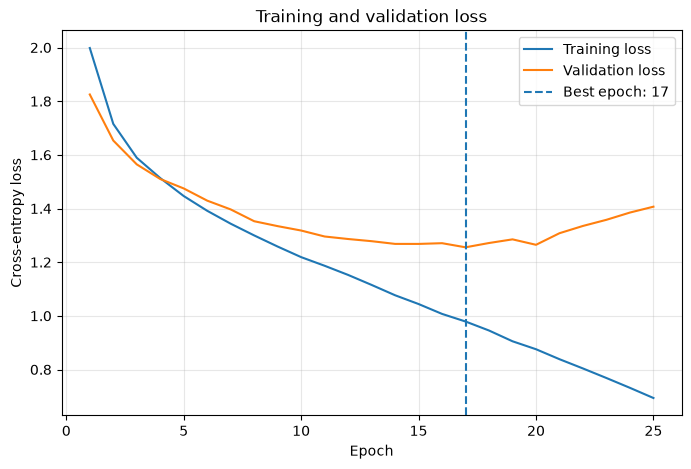

In [50]:
epochs = range(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training loss",
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()